In [1]:

import matplotlib.pyplot as plt
import numpy as nu
#!{sys.executable} -m pip install multipletau
import math
from multipletau import autocorrelate
import array
import lmfit
import scipy as sp
import numpy as np
from os import listdir
import sys, os.path
#from iRheology import *


In [2]:
def ReadTable(filename, beadindx = -1, X=0, Y=1, indx=2, skip=1):
    """ Read a table from a text file. It considers a white spaced
        text table with a filled up rectangular data set (no missing
        points in the table).

        Parameters:
        beadindx:   which column to use to factorize?
        X:          index of x coordinate
        Y:          index of y coordinate
        indx:       index of image index column 
                    (proportional to the time)

        skip:       how many lines to skip at the beginning

        Return:
        a poslist list of dicts (see ImageP track results)
        Each dict holds 'X','Y'(if any), 'indx' keys, from which
        'X','Y' are coordinate arrays, 'indx' is the image index (time).
        The position in poslist is the index of the trajectory (bead).
    """
    if os.path.isfile(filename):
        fp = open(filename, 'rt')
    else:
        print("file not found: %s" %filename) 
        return None
    
    a = fp.readlines()
    fp.close()

    #strip the skip part:
    a = a[skip:]
    Ni = len(a)
    #estimate the number of columns from the first row:
    t = (a[0].strip()).split(',')
    Nj = len(t)-1

    #Now read up the table:
    res = []
    for i in range(Ni):
        t = a[i].strip()
        
        l = []
        t = t.split(',')

        for j in range(Nj):
            if t[j+1]=='':
                continue
            l.append(float(t[j+1]))

        res.append(l)
    #end for i
    print("Found: %d lines" %len(res))

    #congvert to poslist:
    res = nu.asarray(res)
    #how many beads? beadindx is the column holding the counter:
    Nb = nu.unique(res[:,beadindx-1])
    print("Max: %d beads" %len(Nb)) 

    poslist = []
    for i in Nb:

        #bindx highlights those lines containing bead i:
        bindx = (res[:,beadindx-1] == i)
        #poslist is a list of dicts
        #each dict holds 'X', 'Y' for position arrays, 
        #and 'indx' for the image indices (may not be continuous)
        poslist.append({"X":res[bindx,X-1], "Y":res[bindx,Y-1],\
                        "indx":res[bindx,indx-1]})

    print("Found: %d beads" %len(poslist))

    return poslist
#end of ReadTable

import numpy as np
import xml.etree.ElementTree as et
 
def loadxmlTrajs(xmlfile):
    """ 
    Load xml files into a python dictionary with the following structure:
        tracks = {'0': {'nSpots': 20, 'trackData': numpy.array(t, x, y, z) }}
    Tracks should be xml file from 'Export tracks to XML file',
    that contains only track info but not the features.
    Similar to what 'importTrackMateTracks.m' needs.
    """
    try:
        tree = et.parse(xmlfile);
    except OSError:
        print('Failed to read XML file {}.'.format(xlmfile) )
    root =  tree.getroot()
    # print(root.attrib)  # or extract metadata
    nTracks = int(root.attrib['nTracks'])
    tracks = {}
    for i in range(nTracks):
        trackIdx = str(i)
        tracks[trackIdx] = {}
        nSpots = int(root[i].attrib['nSpots'])
        tracks[trackIdx]['nSpots'] = nSpots
        trackData = np.array([ ]).reshape(0, 4)
        for j in range(nSpots):
            t = float(root[i][j].attrib['t'])
            x = float(root[i][j].attrib['x'])
            y = float(root[i][j].attrib['y'])
            z = float(root[i][j].attrib['z'])
            spotData = np.array([t, x, y, z])
            trackData = np.vstack((trackData, spotData))
        tracks[trackIdx]['trackData'] = trackData
    return tracks
    # Dump the dictionary with json or pickle it as you want

In [3]:
import os

testdir = r"D:\Anurag_data\Fast tracking\WT A1-LCD\Sample 3\Condensate 2\2ms_1\Cropped"
os.listdir(testdir)
os.chdir(testdir)
os.getcwd()
files = listdir()
scans = []
fraps=[]
for file in files:
    if '.xml' in file  :
        scans.append(file)
index = np.arange(len(scans))
insca = zip(list(index),scans)
list(insca)
scans

['2ms_1_MMStack_Pos0_Tracks.xml']

In [4]:
index_to_analyze = 0

fname=scans[index_to_analyze]

pos= loadxmlTrajs(fname)

In [5]:
pixel_conversion=1
frametime= 0.002 #in seconds
R=0.1 #in microns
T = 19.0 #in Celsius

In [14]:
# now we do the center of mass function
def com_func(posdict):
    '''
    Parameters:
        posdict: each dict holds 'bead' key which holds a dict with 'X','Y', and 'time' keys from which
        'X','Y' are coordinate arrays, 'time' a time array
    
    Return:
        comX: array of the center of mass position X
        comY: array of the center of mass position Y
    '''
    # first, create the full time list, each element is distinct and contains each time possibility
    full_time = [i for i in range(2000)]
    
    #print(full_time)
    posdict2 = {}
    for key in posdict.keys():
        posdict2[key] = {'time':[], 'X':[], 'Y':[]}
    
    for key in posdict.keys():
        posdict2[key]['time'] = [i for i in posdict[key]['trackData'][:,0]]
        posdict2[key]['X'] = [i for i in posdict[key]['trackData'][:,1]]
        posdict2[key]['Y'] = [i for i in posdict[key]['trackData'][:,2]]
    
    # iterate over each time, see if it is in a bead's track time then add the x and y values to the comX and comY
    comX = []
    comY = []
    counts=[]
    for t in full_time:
        count = 0
        X_tot = 0
        Y_tot = 0
        for key in posdict2.keys():
            if t in posdict2[key]['time']:
                index = posdict2[key]['time'].index(t)
                count += 1
                X_tot += posdict2[key]['X'][index]
                Y_tot += posdict2[key]['Y'][index]
        comX.append(X_tot/count)
        comY.append(Y_tot/count)
        counts.append(count)
    
    return np.array(comX), np.array(comY), counts

In [15]:
def com_func2(posdict):
    '''
    Parameters: 
        posdict = {'0': {'nSpots': 20, 'trackData': numpy.array(t, x, y, z) }}
        the input looks akin to this ^
    
    Returns:
        comX: numpy array of the center of mass in x
        comY: numpy array of the center of mass in y
        counts: list of the number particles in each frame
    '''
    
    # the entire time of data collection
    full_time = [i for i in range(2000)]
    
    # now, we simply need a bunch of differences? np.gradient?
    # we create a new dictionary where it uses the gradients instead of the raw tracks
    # veldict = {'0': {'nSpots': 20, 'trackData': [t, x, y, z]  }}
    veldict = {}
    for key in posdict.keys():
        veldict[key] = {'nSpots': 0, 'trackData':[]}
    
    for key in veldict.keys():
        veldict[key]['nSpots'] = posdict[key]['nSpots']
        veldict[key]['trackData'].append(posdict[key]['trackData'][:,0])
        veldict[key]['trackData'].append( np.gradient(posdict[key]['trackData'][:,1], posdict[key]['trackData'][:,0]))
        veldict[key]['trackData'].append( np.gradient(posdict[key]['trackData'][:,2], posdict[key]['trackData'][:,0]))
        veldict[key]['trackData'].append( np.gradient(posdict[key]['trackData'][:,3], posdict[key]['trackData'][:,0]))
    
    # now that we have these, we can get the average ensamble velocity
    velX = []
    velY = []
    counts=[]
    for t in full_time:
        count = 0
        vX_tot = 0
        vY_tot = 0
        for key in veldict.keys():
            if t in veldict[key]['trackData'][0]:
                index = np.ndarray.tolist(veldict[key]['trackData'][0]).index(t)
                count += 1
                vX_tot += veldict[key]['trackData'][1][index]
                vY_tot += veldict[key]['trackData'][2][index]
        velX.append(vX_tot/count)
        velY.append(vY_tot/count)
        counts.append(count)
    
    # okay, now I have the new velocities we need the initial position
    x0 = 0
    y0 = 0
    count = 0
    for key in posdict.keys():
        if 0 in veldict[key]['trackData'][0]:
            count += 1
            x0 += posdict[key]['trackData'][0,1]
            y0 += posdict[key]['trackData'][0,2]
    x0 = x0/count
    y0 = y0/count
    
    # finally, all we need is the final comX, comY, and counts
    comX = [x0 + sum(velX[:i]) for i in full_time]
    comY = [y0 + sum(velY[:i]) for i in full_time]
    
    return np.array(comX), np.array(comY), counts

In [16]:
'''
sizes = np.zeros((len(pos),))
for i in range(len(pos)): 
    sizes[i]=pos[str(i)]['nSpots']
lastframe=min(sizes)
XCOM=np.zeros((int(lastframe),))
YCOM=np.zeros((int(lastframe),))
for i in range(int(lastframe)):
    Xavg=0
    Yavg=0
    for j in range(len(pos)):
        Xavg=Xavg+pos[str(j)]['trackData'][i,1]*pixel_conversion
        Yavg=Yavg+pos[str(j)]['trackData'][i,2]*pixel_conversion
    XCOM[i]=Xavg/len(pos)
    YCOM[i]=Yavg/len(pos)
'''
XCOM, YCOM, counts = com_func2(pos)

In [17]:
temp = counts[0]
index = 0
for each in counts:
    if each != temp:
        #print(index)
        temp = each
    index += 1

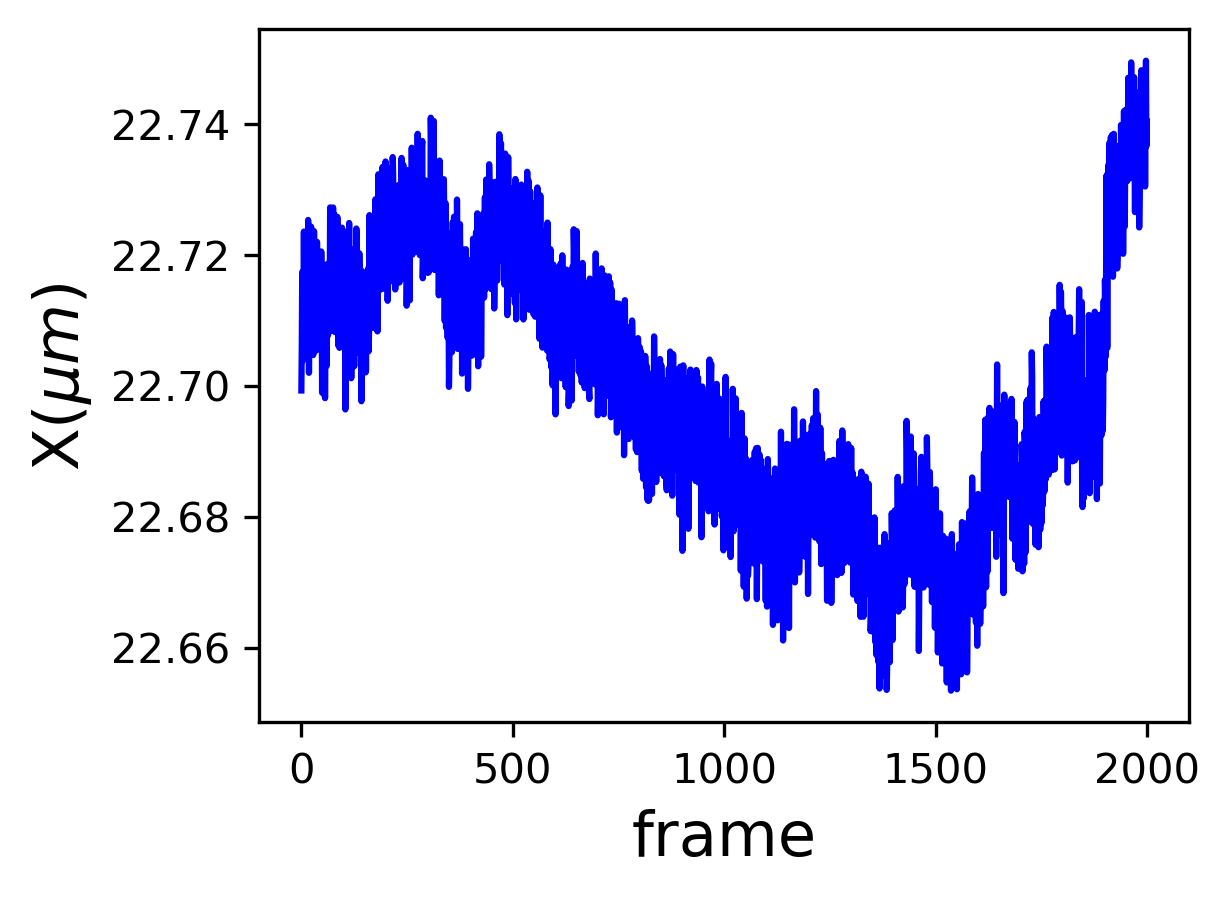

In [18]:
plt.figure(figsize=(4,3),dpi=300)
plt.plot(XCOM, 'b')
plt.xlabel('frame',fontsize=15)
plt.ylabel('X($\mu m$)',fontsize=15)
plt.savefig(fname+'XCOM.svg',bbox_inches='tight')
plt.savefig(fname+'XCOM.png',bbox_inches='tight')
#np.savetxt("COM_trajectory.txt",np.transpose([np.arange(int(lastframe)), XCOM,YCOM]),delimiter='\t')

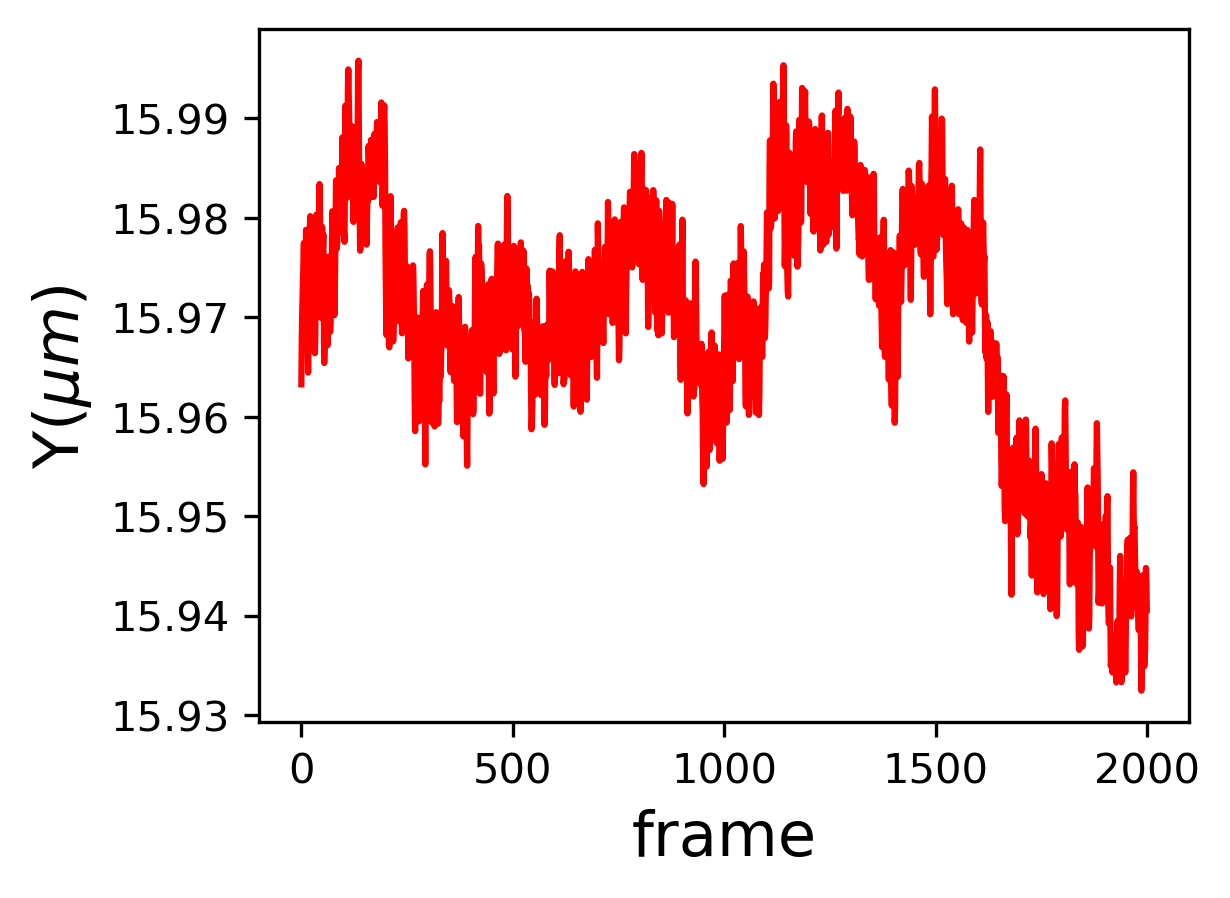

In [19]:
plt.figure(figsize=(4,3),dpi=300)
plt.plot(YCOM,'r')
plt.xlabel('frame',fontsize=15)
plt.ylabel('Y($\mu m$)',fontsize=15)
plt.savefig(fname+'YCOM.svg',bbox_inches='tight')
plt.savefig(fname+'YCOM.png',bbox_inches='tight')
#np.savetxt("COM_trajectory.txt",np.transpose([np.arange(int(lastframe)), XCOM,YCOM]),delimiter='\t')

In [20]:

#len(np.arange(len(pos)))
#lastframe

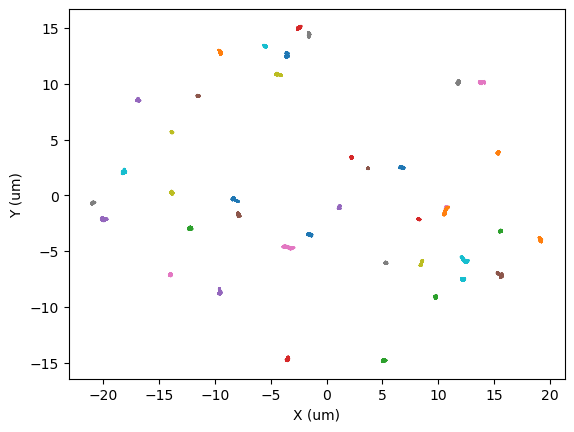

In [25]:

msds = []
xpos=[]
ypos=[]
i=[]
msdsizes=[]
for l in range(len(pos)):
    #ind=pos[str(l)]['indx'][0:int(lastframe)]
    first = int(pos[str(l)]['trackData'][0,0])
    last = int(pos[str(l)]['trackData'][-1,0])+1
    if last-first >= 200:
        #print(first, last)
        xpos=pos[str(l)]['trackData'][:,1]*pixel_conversion-XCOM[first:last]
        ypos=pos[str(l)]['trackData'][:,2]*pixel_conversion-YCOM[first:last]
        #a,b=np.polyfit(ind,xpos,1)
        #error = a*ind+b
        #xpos = xpos-error 
        #a,b=np.polyfit(ind,ypos,1)
        #error = a*ind+b
        #ypos = ypos-error 
        plt.plot(xpos,ypos)
        nData = len(xpos)
        numberOfdeltaT = int(nData/4)
        msd = np.zeros((numberOfdeltaT,4))


        k=0
        for dt in range(numberOfdeltaT+1):
            if dt==0:
                continue
            deltax = xpos[1+dt:len(xpos)-1]-xpos[1:len(xpos)-1-dt]
            deltay = ypos[1+dt:len(ypos)-1]-ypos[1:len(ypos)-1-dt]

            sD = deltax**2+deltay**2
            msd[k,0]  =frametime*dt
            msd[k,1]  =np.mean(sD)
            msd[k,2]  =np.std(sD)
            msd[k,3]  =len(sD)
            k=k+1
        msds.append({"time":msd[:,0], "MSD":msd[:,1],"DMSD":msd[:,2], "MSDsize":len(msd)})
        msdsizes.append(len(msd))
   
        xpos=[]
        ypos=[]
        i=[]

        plt.xlabel('X (um)')
        plt.ylabel('Y (um)')
    plt.savefig(fname+'tracks.png')

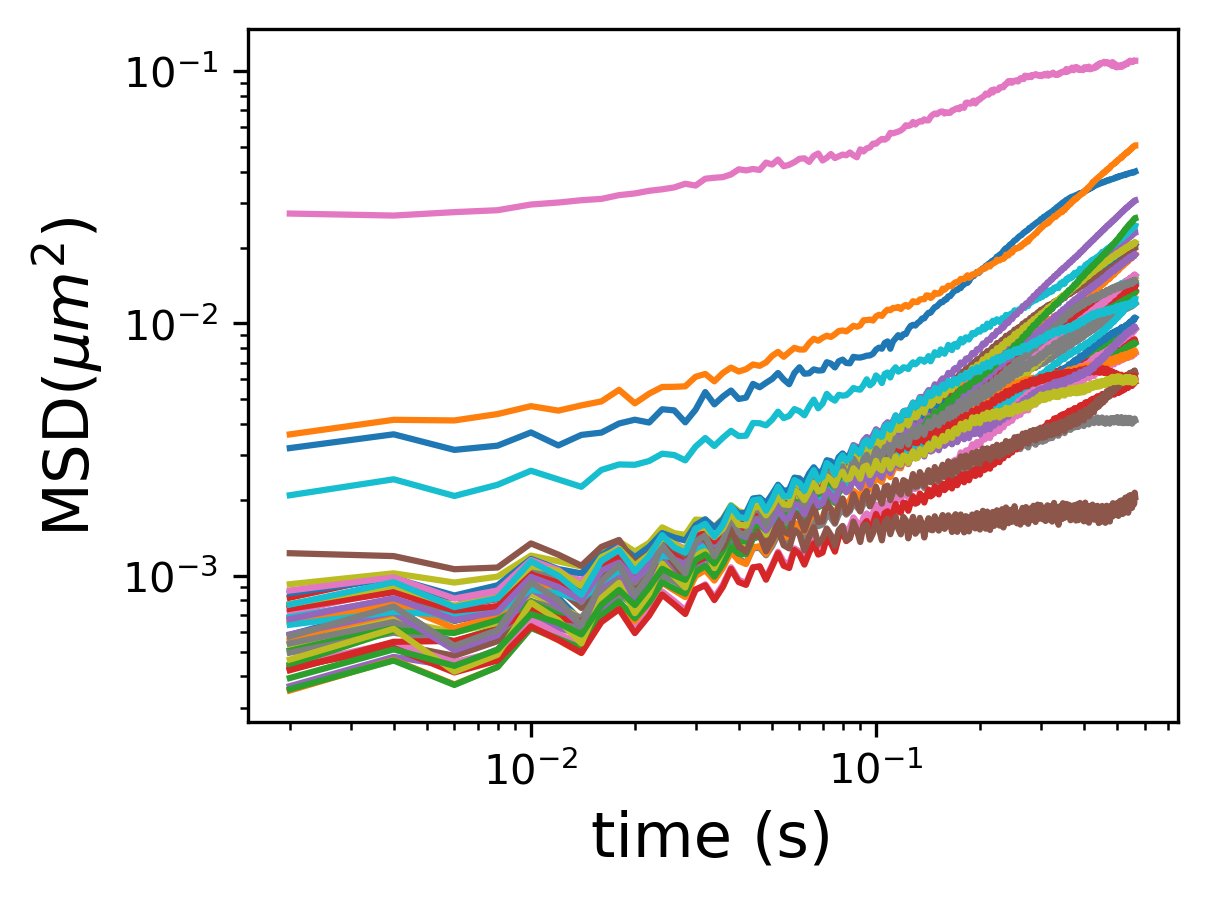

In [23]:
lastind=np.min(msdsizes)-1
totmsd =np.zeros((lastind,))
msd_all=np.zeros((lastind,len(msds)))
plt.figure(figsize=(4,3),dpi=300)

plt.xlabel('time (s)',fontsize=15)
plt.ylabel('MSD($\mu m^2$)',fontsize=15)


for i in range(len(msds)):
    mmd = np.array(msds[i]['MSD'])
    time= msds[i]['time']
    if mmd[lastind]<2.0e-9 or mmd[0]>1.0e4:
        continue
    plt.loglog(time[:lastind],mmd[:lastind])
    totmsd=totmsd+mmd[0:lastind]
plt.savefig(fname+'MSDs_all.svg',bbox_inches='tight')
plt.savefig(fname+'MSDs_all.png',bbox_inches='tight')
msdavg= totmsd/len(msds)
time=time[0:lastind]
#plt.loglog(time,msdavg,'o')
np.savetxt(fname+'MSD_new.txt',np.transpose([time,msdavg]), delimiter='\t')   # X is an array



In [536]:
msd_all=np.zeros((lastind,len(msds)))

[[Model]]
    Model(MSDfitfit)
[[Fit Statistics]]
    # fitting method   = least_squares
    # function evals   = 10
    # data points      = 225
    # variables        = 3
    chi-square         = 4.7447e-08
    reduced chi-square = 2.1372e-10
    Akaike info crit   = -5006.94507
    Bayesian info crit = -4996.69677
    R-squared          = 0.99993585
[[Variables]]
    D:      6.4069e-05 +/- 3.4882e-07 (0.54%) (init = 0.2)
    alpha:  1.02620258 +/- 0.00165523 (0.16%) (init = 1)
    N:      5.0000e-05 +/- 3.8595e-06 (7.72%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(D, alpha) = -0.995
    C(D, N)     = -0.904
    C(alpha, N) = 0.866


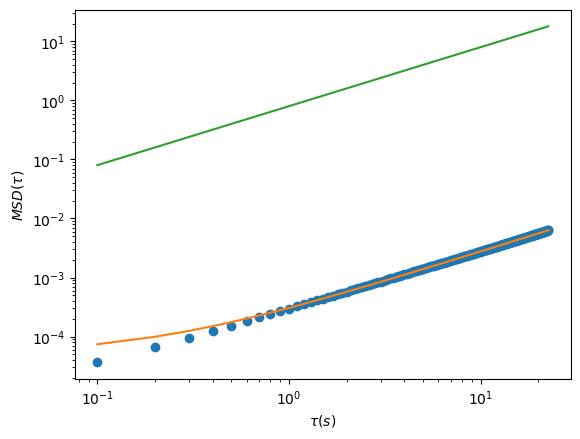

In [546]:
def MSDfitfit(t, D,alpha,N):
    return 4*D*t**alpha + N

modely = lmfit.Model(MSDfitfit)
params = modely.make_params(D=1.,alpha=1.,N=0)


params['D'].set(value=.2, vary=True)
params['alpha'].set(value=1.0, vary=True)
params['N'].set(value=0.,max=0.00005,min=0., vary=True)

start=0
end=500

fitresy = modely.fit(msdavg[start:end], t=time[start:end], params=params ,method='least_squares')
print(fitresy.fit_report())

plt.loglog(time[start:end],msdavg[start:end],'o')
plt.loglog(time[start:end], fitresy.best_fit)
plt.loglog(time[start:end], fitresy.init_fit)
plt.xlabel(r'$\tau (s)$')
plt.ylabel(r'$MSD(\tau)$')
#plt.savefig(fname+'MSDfit.png',bbox_inches='tight')
timenew=np.logspace(-5,1,1000000)
#Jnew=modely.eval(fitresy.params,t=timenew)
#np.savetxt(fname+'MSDandfit.txt',np.transpose([time[start:end],msdavg[start:end],fitresy.best_fit]))

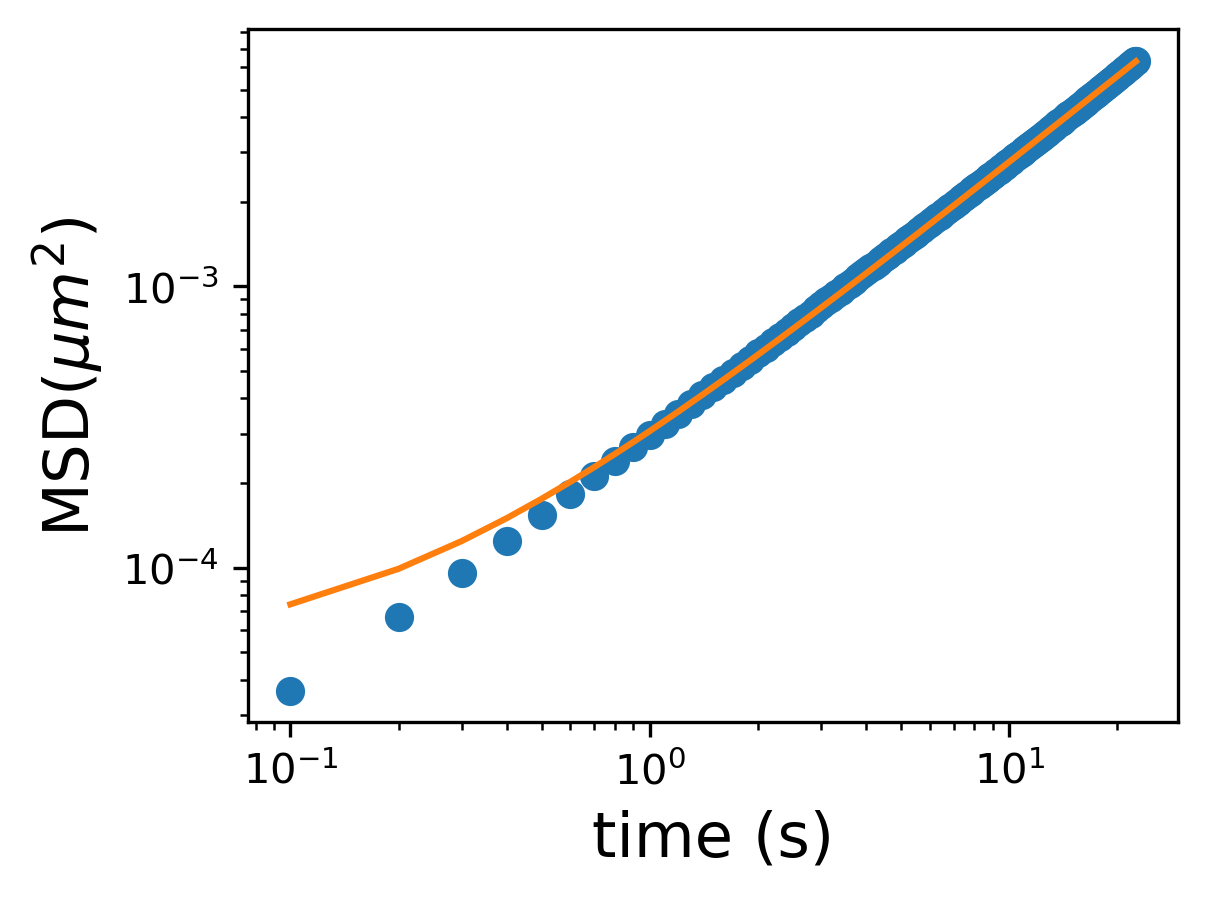

In [547]:
plt.figure(figsize=(4,3),dpi=300)
plt.loglog(time[start:end],msdavg[start:end],'o')
plt.loglog(time[start:end], fitresy.best_fit)

plt.xlabel('time (s)',fontsize=15)
plt.ylabel('MSD($\mu m^2$)',fontsize=15)
plt.savefig(fname+'MSDs_fit.svg',bbox_inches='tight')
plt.savefig(fname+'MSDs_fit.png',bbox_inches='tight')

In [548]:

k=  1.38064852e-23 #boltzmann const

const = 1e18*k/(6*np.pi)
eta = const*(T+273.15)/(R*fitresy.best_values['D'])
eta # in Pa.s

33.399431397710295

In [549]:
import csv
f = open(fname+'_fitting_report.txt','w')
f.write(fitresy.fit_report())
f.close()
out=open('fitting_params.txt','a')
line_exp = str(fitresy.best_values['D'])+'\t'+str(fitresy.best_values['alpha'])+'\t'+str(fitresy.best_values['N'])
out.write(str(line_exp)+'\n')
out.close()
out=open('viscosity.txt','a')
out.write(str(eta)+'\n')
out.close()